# פרויקט מדעי הנתונים – חיזוי נשירת סטודנטים
## הכפר הירוק, כיתה י'

**שם התלמיד:** עידן עטר | ת"ז: 318074846

**שם המורה:** ענת שפיר

**מטרת המחקר:** לחזות אם תלמיד נשר מאוניברסיטה או לא, באמצעות מודלים של למידת מכונה.

**מקור הנתונים:** [Kaggle – Student Dropout Prediction Dataset](https://www.kaggle.com/datasets/meharshanali/student-dropout-prediction-dataset)

## פירוט על המאגר

המאגר מכיל מידע על סטודנטים ונשירתם מאוניברסיטה. להלן העמודות:

- **Student_ID:** מזהה סטודנט ייחודי.
- **Age:** גיל הסטודנט בשנים.
- **Gender:** Male / Female (מין).
- **Family_Income:** הכנסה משפחתית (Low / Medium / High).
- **GPA:** ציון ממוצע (0–4).
- **Attendance_Rate:** אחוז נוכחות (0–100).
- **Study_Hours_per_Day:** שעות לימוד יומיות.
- **Assignment_Delay_Days:** ימי עיכוב בהגשות.
- **Stress_Index:** מדד סטרס (0–1).
- **Dropout:** משתנה מטרה – 1 = נשר, 0 = לא נשר.

## חלק א' – טעינת ספריות

בבלוק הבא אנחנו מייבאים את כל הספריות שנצטרך לאורך הפרויקט:
- **pandas** ו-**numpy** – לעיבוד ולניתוח נתונים.
- **matplotlib** ו-**seaborn** – להצגת גרפים ותרשימים.
- **sklearn** – ספריית למידת מכונה: חלוקה, נרמול, מודלים, ומדדי הערכה.
- **imblearn** – לטיפול בחוסר איזון בנתונים באמצעות SMOTE.
- **kagglehub** – להורדת מאגר הנתונים ישירות מ-Kaggle.

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import warnings
warnings.filterwarnings('ignore')
import itertools
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, make_scorer)
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier


## טעינת הנתונים

בבלוק הבא אנחנו מורידים את מאגר הנתונים מ-Kaggle ומטעינים אותו לטבלה (DataFrame).
הפקודה `kagglehub.dataset_download` מורידה את הקובץ, ואנחנו מוצאים את קובץ ה-CSV ומטעינים אותו עם `pd.read_csv`.
לבסוף מדפיסים את 5 השורות הראשונות כדי לוודא שהנתונים נטענו כראוי.

In [2]:
path = kagglehub.dataset_download("meharshanali/student-dropout-prediction-dataset")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, csv_files[0]))

print("הנתונים נטענו בהצלחה!")
print(f"מספר שורות: {df.shape[0]}, מספר עמודות: {df.shape[1]}")
print()
df.head()

הנתונים נטענו בהצלחה!
מספר שורות: 10000, מספר עמודות: 19



,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


## סקירה ראשונית של הנתונים (EDA)

לפני שמתחילים לעבד את הנתונים, חשוב להכיר אותם:
- **df.info()** – מראה את סוגי העמודות, כמה ערכים לא ריקים יש בכל עמודה, וצריכת הזיכרון. זה עוזר לנו להבין אם יש עמודות שחסרים בהן ערכים ומה הטיפוס של כל עמודה.
- **df.describe()** – מחשב סטטיסטיקות בסיסיות (ממוצע, חציון, סטיית תקן, מינימום, מקסימום) לכל עמודה מספרית. זה עוזר לזהות טווחי ערכים חריגים.
- **df.duplicated()** – בודק אם יש שורות כפולות במאגר, כי כפילויות עלולות להטות את המודל.

In [3]:
print("=" * 60)
print("מבנה הנתונים - df.info()")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("סטטיסטיקות תיאוריות - df.describe()")
print("=" * 60)
df.describe()

מבנה הנתונים - df.info()
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  str    
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  str    
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  str    
 10  Scholarship            10000 non-null  str    
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  fl

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [4]:
print("=" * 60)
print("סטטיסטיקות לעמודות קטגוריאליות")
print("=" * 60)
df.describe(include='object')

סטטיסטיקות לעמודות קטגוריאליות


,Gender,Internet_Access,Part_Time_Job,Scholarship,Semester,Department,Parental_Education
count,10000,10000,10000,10000,10000,10000,9489
unique,2,2,2,2,4,5,4
top,Female,Yes,No,No,Year 4,Science,Bachelor
freq,5011,8769,5996,6489,2536,2061,3949


### בדיקת כפילויות

בודקים אם יש שורות זהות לחלוטין. שורות כפולות עלולות להטות את תוצאות המודל כי הן מכפילות דוגמאות זהות.

In [5]:
num_duplicates = df.duplicated().sum()
print(f"מספר שורות כפולות: {num_duplicates}")

if num_duplicates > 0:
    df = df.drop_duplicates()
    print(f"שורות אחרי הסרת כפילויות: {len(df)}")
else:
    print("אין שורות כפולות – הנתונים נקיים מכפילויות.")

מספר שורות כפולות: 0
אין שורות כפולות – הנתונים נקיים מכפילויות.


### בדיקת ערכים חסרים

ערכים חסרים (NaN) עלולים לגרום לשגיאות באימון המודל. בודקים כמה ערכים חסרים יש בכל עמודה ומחליטים איך לטפל בהם.

In [6]:
print("ערכים חסרים לפי עמודה:")
print(df.isnull().sum())
print(f"\nסך הכל שורות עם ערך חסר: {df.isnull().any(axis=1).sum()}")
print(f"אחוז השורות עם ערך חסר: {df.isnull().any(axis=1).mean():.1%}")

ערכים חסרים לפי עמודה:
Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

סך הכל שורות עם ערך חסר: 980
אחוז השורות עם ערך חסר: 9.8%


### המרת משתנים קטגוריאליים

חלק מהעמודות במאגר הן קטגוריאליות (טקסט), כמו Gender ו-Family_Income.
מודלים של למידת מכונה לא יכולים לעבוד עם טקסט, ולכן צריך להמיר אותן למספרים.

נשתמש ב-**LabelEncoder** שממיר כל קטגוריה למספר. לדוגמה:
- Gender: Male → 1, Female → 0
- Family_Income: Low → 1, Medium → 2, High → 0

חשוב לעשות את ההמרה לפני שמוחקים שורות, כדי לא לאבד מידע שימושי.

In [7]:
label_encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("עמודות קטגוריאליות שנמצאו:", categorical_cols)
print()

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nכל המשתנים הקטגוריאליים הומרו למספרים בהצלחה.")

עמודות קטגוריאליות שנמצאו: ['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']

  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Internet_Access: {'No': np.int64(0), 'Yes': np.int64(1)}
  Part_Time_Job: {'No': np.int64(0), 'Yes': np.int64(1)}
  Scholarship: {'No': np.int64(0), 'Yes': np.int64(1)}
  Semester: {'Year 1': np.int64(0), 'Year 2': np.int64(1), 'Year 3': np.int64(2), 'Year 4': np.int64(3)}
  Department: {'Arts': np.int64(0), 'Business': np.int64(1), 'CS': np.int64(2), 'Engineering': np.int64(3), 'Science': np.int64(4)}
  Parental_Education: {'Bachelor': np.int64(0), 'High School': np.int64(1), 'Master': np.int64(2), 'PhD': np.int64(3), nan: np.int64(4)}

כל המשתנים הקטגוריאליים הומרו למספרים בהצלחה.


### ניקוי ערכים חסרים

לאחר ההמרה, מסירים שורות שנותרו עם ערכים חסרים. האחוז נמוך ולכן ההסרה לא תשפיע מהותית על הנתונים.

In [8]:
print(f"שורות לפני ניקוי: {len(df)}")
df_cleaned = df.dropna()
print(f"שורות אחרי ניקוי: {len(df_cleaned)}")
print(f"שורות שהוסרו: {len(df) - len(df_cleaned)}")

שורות לפני ניקוי: 10000


שורות אחרי ניקוי: 9500
שורות שהוסרו: 500


### בדיקת חריגים (Outliers)

חריגים הם ערכים קיצוניים שנמצאים רחוק מרוב הנתונים. הם עלולים להטעות את המודל.
נשתמש בשיטת **IQR (Interquartile Range)**:
- מחשבים את הרבעון הראשון (Q1) והשלישי (Q3).
- IQR = Q3 - Q1
- ערך חריג הוא כל ערך שנמוך מ-Q1 - 1.5×IQR או גבוה מ-Q3 + 1.5×IQR.

במקום למחוק חריגים (מה שעלול להקטין מאוד את המאגר), נבצע **חיתוך (clipping)** – נעגל את הערכים הקיצוניים לגבולות.

In [9]:
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Student_ID', 'Dropout']]

print("בדיקת חריגים בעמודות מספריות (שיטת IQR):")
print("-" * 50)

outlier_counts = {}
for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_cleaned[col] < lower) | (df_cleaned[col] > upper)).sum()
    outlier_counts[col] = n_outliers
    if n_outliers > 0:
        print(f"  {col}: {n_outliers} חריגים (טווח תקין: {lower:.2f} – {upper:.2f})")

if sum(outlier_counts.values()) == 0:
    print("  לא נמצאו חריגים בשום עמודה.")
else:
    print(f"\nסך הכל חריגים: {sum(outlier_counts.values())}")
    print("מבצעים clipping – חיתוך ערכים קיצוניים לגבולות:")
    for col in numeric_cols:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_cleaned[col] = df_cleaned[col].clip(lower, upper)
    print("  החיתוך בוצע בהצלחה.")

בדיקת חריגים בעמודות מספריות (שיטת IQR):
--------------------------------------------------
  Age: 33 חריגים (טווח תקין: 15.00 – 27.00)
  Family_Income: 604 חריגים (טווח תקין: -4280.00 – 73800.00)
  Internet_Access: 1160 חריגים (טווח תקין: 1.00 – 1.00)
  Study_Hours_per_Day: 86 חריגים (טווח תקין: 0.60 – 7.44)
  Attendance_Rate: 23 חריגים (טווח תקין: 60.40 – 103.60)
  Assignment_Delay_Days: 24 חריגים (טווח תקין: -2.00 – 6.00)


  Travel_Time_Minutes: 25 חריגים (טווח תקין: -2.85 – 63.15)

סך הכל חריגים: 1955
מבצעים clipping – חיתוך ערכים קיצוניים לגבולות:


  החיתוך בוצע בהצלחה.


## חלק ב' – ויזואליזציה וניתוח גרפי

### גרף 1: מפה תרמית (Heatmap) של קורלציות

מפה תרמית מראה את הקשר (קורלציה) בין כל זוג משתנים מספריים. ערך קרוב ל-1 או ל-(-1) אומר שיש קשר חזק בין שני המשתנים, וערך קרוב ל-0 אומר שאין קשר. זה עוזר לנו לבחור את הפיצ'רים הכי רלוונטיים לחיזוי נשירה.

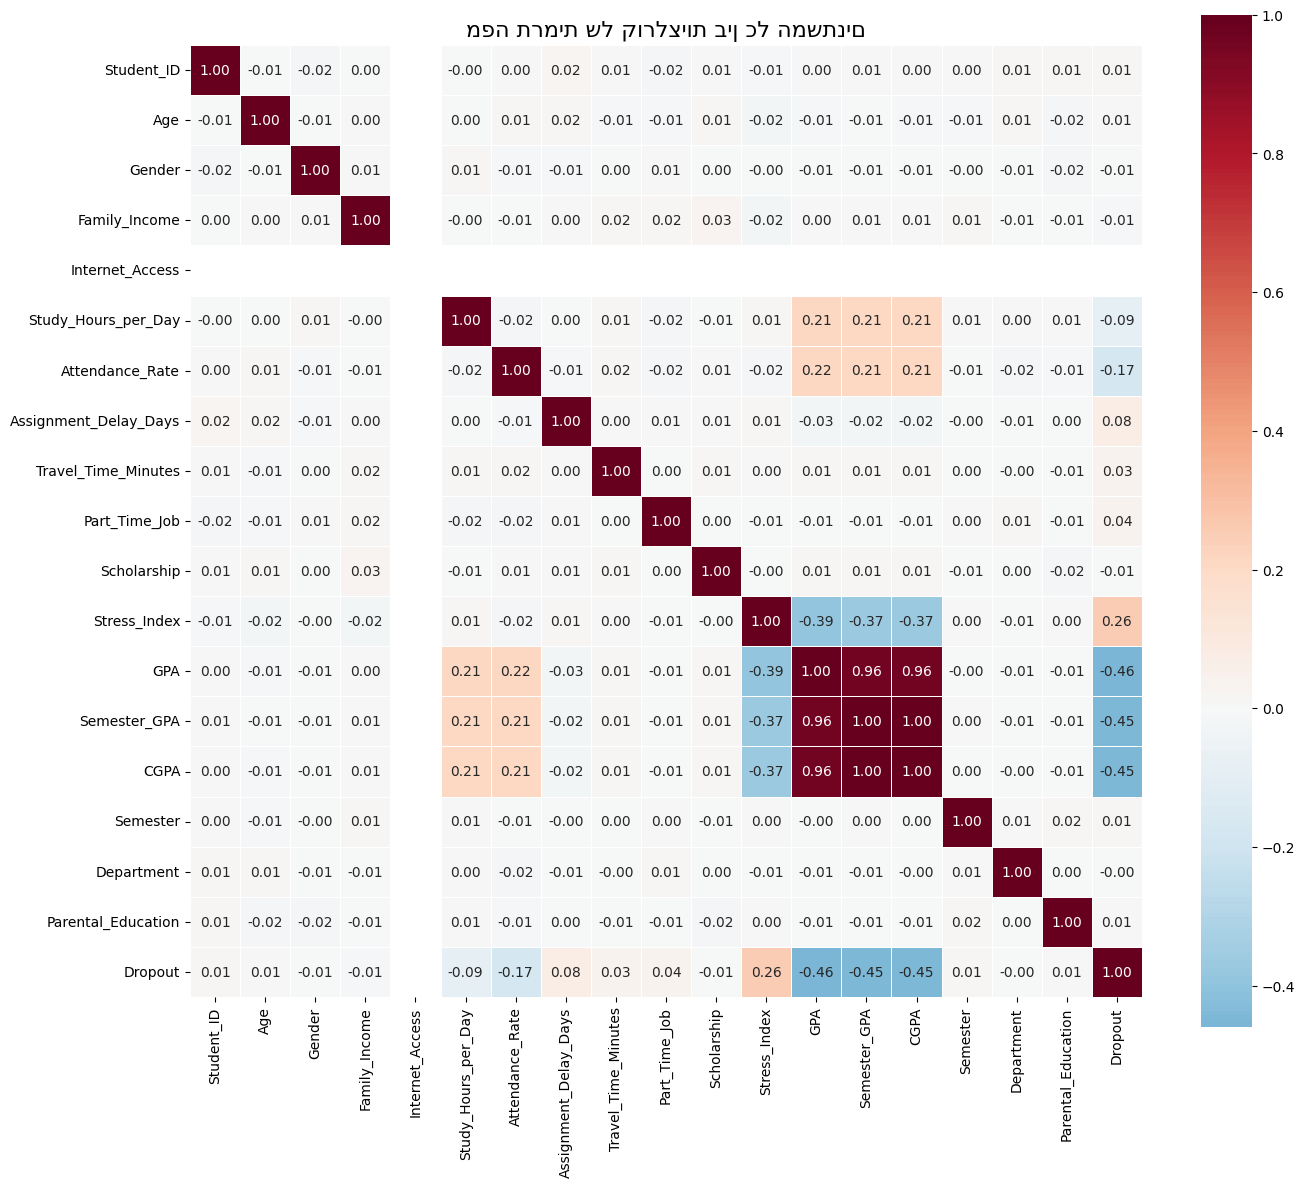

In [10]:
numeric_df = df_cleaned.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            linewidths=0.5,
            square=True)

plt.title("מפה תרמית של קורלציות בין כל המשתנים", fontsize=16)
plt.tight_layout()
plt.show()

### גרף 2: תרשים עמודות (Bar Chart) – ממוצע משתנים לפי סטטוס נשירה

תרשים עמודות מאפשר להשוות בין קבוצות שונות. נבדוק את הממוצע של מדד הסטרס (Stress_Index) ושל ימי עיכוב בהגשות (Assignment_Delay_Days) בין סטודנטים שנשרו לכאלה שלא, כדי לראות האם יש הבדלים משמעותיים.

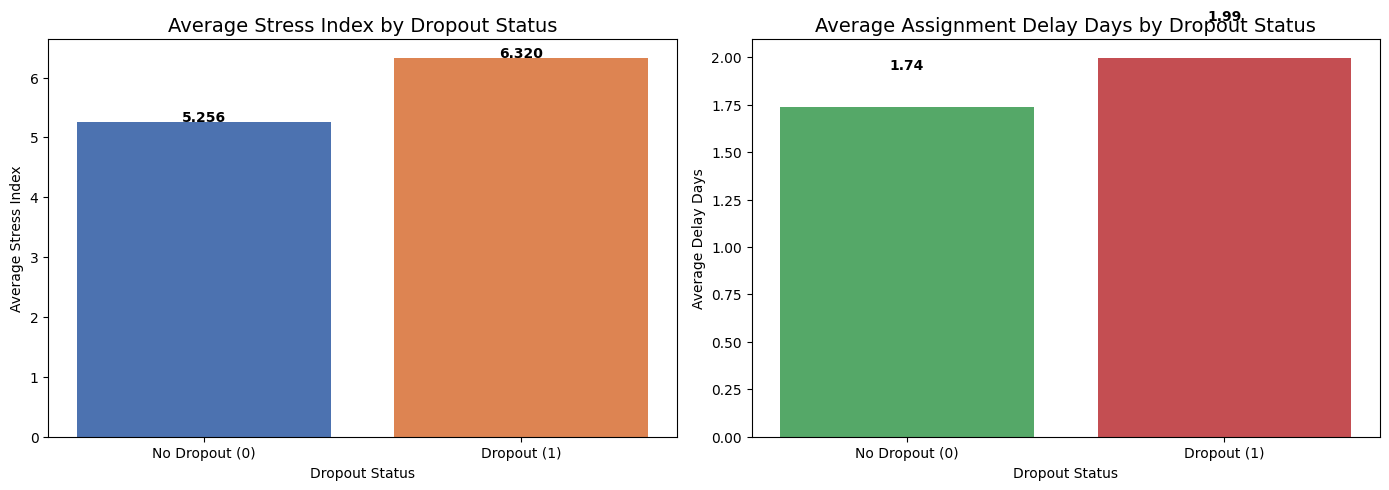

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stress_Index by Dropout
stress_means = df_cleaned.groupby('Dropout')['Stress_Index'].mean()
labels = ['No Dropout (0)', 'Dropout (1)']
axes[0].bar(labels, stress_means.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Average Stress Index by Dropout Status', fontsize=14)
axes[0].set_ylabel('Average Stress Index')
axes[0].set_xlabel('Dropout Status')
for i, v in enumerate(stress_means.values):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Assignment_Delay_Days by Dropout
delay_means = df_cleaned.groupby('Dropout')['Assignment_Delay_Days'].mean()
axes[1].bar(labels, delay_means.values, color=['#55A868', '#C44E52'])
axes[1].set_title('Average Assignment Delay Days by Dropout Status', fontsize=14)
axes[1].set_ylabel('Average Delay Days')
axes[1].set_xlabel('Dropout Status')
for i, v in enumerate(delay_means.values):
    axes[1].text(i, v + 0.2, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### גרף 3: תרשים קופסה (Box Plot) – התפלגות משתנים לפי סטטוס נשירה

Box Plot מציג את ההתפלגות של כל משתנה: החציון, הרבעונים, הטווח, ואת הערכים החריגים. נשווה את ההתפלגויות בין סטודנטים שנשרו לכאלה שלא, כדי לראות אילו משתנים שונים משמעותית בין שתי הקבוצות.

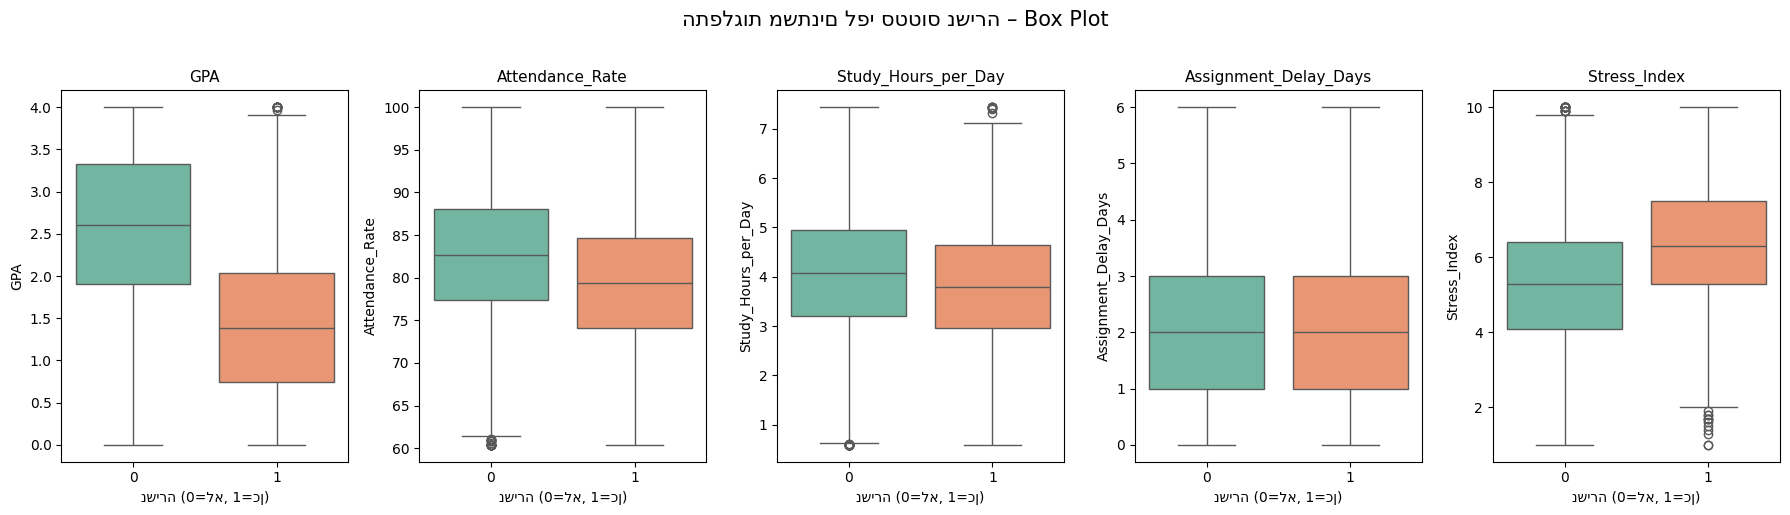

In [12]:
plot_features = ['GPA', 'Attendance_Rate', 'Study_Hours_per_Day', 'Assignment_Delay_Days', 'Stress_Index']

fig, axes = plt.subplots(1, len(plot_features), figsize=(18, 5))

for i, col in enumerate(plot_features):
    sns.boxplot(x='Dropout', y=col, data=df_cleaned, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('נשירה (0=לא, 1=כן)')

plt.suptitle('התפלגות משתנים לפי סטטוס נשירה – Box Plot', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### בחירת פיצ'רים (Feature Selection)

לפי המפה התרמית, הערכים בעלי הקורלציה הכי גבוהה עם Dropout הם:
Stress_Index, GPA, Assignment_Delay_Days, Attendance_Rate, Study_Hours_per_Day.

נבדוק את כל הצירופים האפשריים שלהם כדי למצוא את קבוצת הפיצ'רים שנותנת את התוצאה הטובה ביותר.
לבדיקה נשתמש במודל **KNN** (K-Nearest Neighbors) כי הוא מהיר ופשוט, ומתאים לסינון ראשוני של פיצ'רים.
חשוב: החלוקה ל-train/test נעשית **לפני** בחירת הפיצ'רים, כדי למנוע דליפת מידע (data leakage).

In [13]:
CANDIDATE_FEATURES = [
    "Stress_Index",
    "GPA",
    "Assignment_Delay_Days",
    "Attendance_Rate",
    "Study_Hours_per_Day",
]

TARGET = "Dropout"

x_all = df_cleaned[CANDIDATE_FEATURES]
y_all = df_cleaned[TARGET].values

x_train_fs, x_test_fs, y_train_fs, y_test_fs = train_test_split(
    x_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Train size: {len(x_train_fs)}, Test size: {len(x_test_fs)}")
print(f"בחירת פיצ'רים תתבצע רק על סט האימון (ללא דליפה).")

subsets = []
for size in range(2, len(CANDIDATE_FEATURES) + 1):
    for combo in itertools.combinations(CANDIDATE_FEATURES, size):
        subsets.append(list(combo))

print(f"מספר צירופים לבדיקה: {len(subsets)}")
print("=" * 65)

SMOTE_RATIO  = 0.6
CV_FOLDS     = 5
RANDOM_STATE = 42

cv_combo = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

combo_results = []

for combo in subsets:
    X_combo = x_train_fs[combo].values

    pipe = ImbPipeline([
        ("smote",  SMOTE(sampling_strategy=SMOTE_RATIO, random_state=RANDOM_STATE)),
        ("scaler", MinMaxScaler()),
        ("clf",    KNeighborsClassifier(n_neighbors=15, weights='distance')),
    ])

    scores = cross_val_score(pipe, X_combo, y_train_fs,
                             cv=cv_combo, scoring="f1_macro", n_jobs=-1)

    combo_results.append({
        "features":  combo,
        "f1_mean":   scores.mean(),
        "f1_std":    scores.std(),
        "n_features": len(combo),
    })

combo_results.sort(key=lambda r: r["f1_mean"], reverse=True)

print(f"\n{'Rank':<6}{'F1-macro':<22}{'#Feat':<8}{'Features'}")
print("-" * 85)
for rank, r in enumerate(combo_results[:15], 1):
    print(f"{rank:<6}{r['f1_mean']:.4f} +/- {r['f1_std']:.4f}     {r['n_features']:<8}{r['features']}")

best = combo_results[0]
print(f"\nהצירוף המנצח: {best['features']}  (F1-macro: {best['f1_mean']:.4f})")

Train size: 7600, Test size: 1900
בחירת פיצ'רים תתבצע רק על סט האימון (ללא דליפה).
מספר צירופים לבדיקה: 26



Rank  F1-macro              #Feat   Features
-------------------------------------------------------------------------------------
1     0.6937 +/- 0.0110     5       ['Stress_Index', 'GPA', 'Assignment_Delay_Days', 'Attendance_Rate', 'Study_Hours_per_Day']
2     0.6910 +/- 0.0150     4       ['Stress_Index', 'GPA', 'Assignment_Delay_Days', 'Attendance_Rate']
3     0.6884 +/- 0.0124     4       ['Stress_Index', 'GPA', 'Attendance_Rate', 'Study_Hours_per_Day']
4     0.6839 +/- 0.0097     4       ['GPA', 'Assignment_Delay_Days', 'Attendance_Rate', 'Study_Hours_per_Day']
5     0.6816 +/- 0.0135     4       ['Stress_Index', 'GPA', 'Assignment_Delay_Days', 'Study_Hours_per_Day']
6     0.6813 +/- 0.0152     3       ['Stress_Index', 'GPA', 'Attendance_Rate']
7     0.6812 +/- 0.0068     3       ['GPA', 'Attendance_Rate', 'Study_Hours_per_Day']
8     0.6755 +/- 0.0084     3       ['Stress_Index', 'GPA', 'Study_Hours_per_Day']
9     0.6742 +/- 0.0101     2       ['GPA', 'Attendance_Rate']
10   

### הפיצ'רים שנבחרו

הפיצ'רים המנצחים הם: **Stress_Index, GPA, Assignment_Delay_Days, Attendance_Rate**.
צירוף זה נתן את ציון ה-F1-macro הגבוה ביותר בבדיקה על סט האימון.

### גרף 4: תרשים כינור (Violin Plot) – התפלגות הפיצ'רים הנבחרים

Violin Plot משלב בין Box Plot ל-KDE (Kernel Density Estimation). הוא מראה גם את ההתפלגות (הצורה) וגם את הרבעונים. ככה אפשר לראות לא רק את הממוצע והחציון, אלא גם את הצורה המלאה של ההתפלגות – האם היא סימטרית, עם שיא אחד או שניים, וכו'.

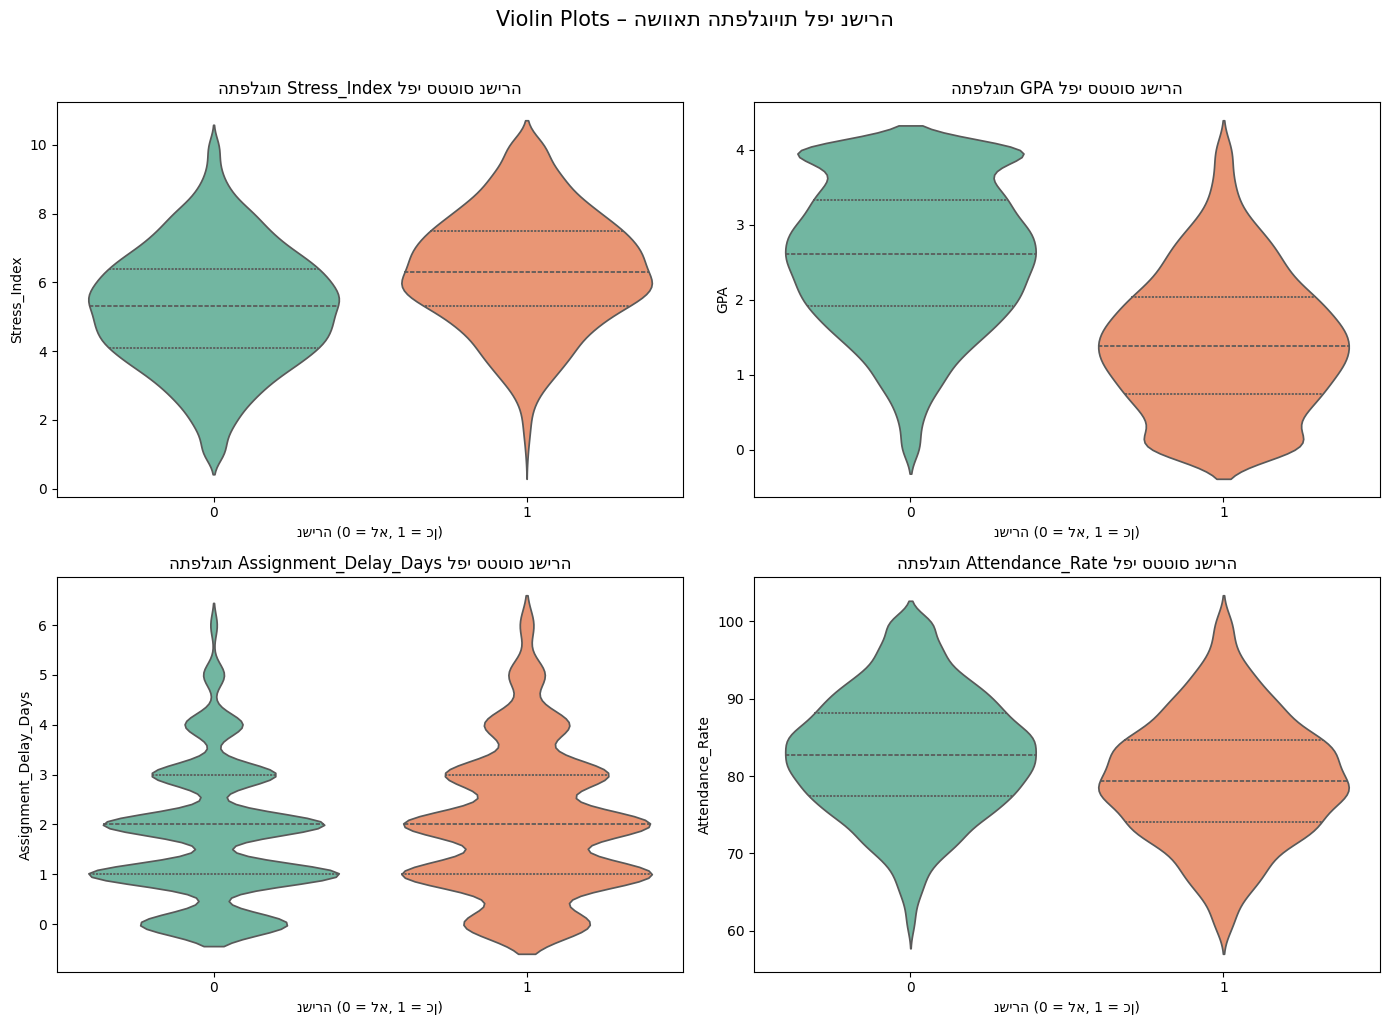

In [14]:
FEATURES = ['Stress_Index', 'GPA', 'Assignment_Delay_Days', 'Attendance_Rate']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    sns.violinplot(x='Dropout', y=col, data=df_cleaned, ax=axes[i], palette="Set2", inner="quartile")
    axes[i].set_title(f'התפלגות {col} לפי סטטוס נשירה', fontsize=12)
    axes[i].set_xlabel('נשירה (0 = לא, 1 = כן)')
    axes[i].set_ylabel(col)

plt.suptitle('Violin Plots – השוואת התפלגויות לפי נשירה', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### גרף 5: תרשים רדאר (Radar Chart) – פרופיל סטודנט

תרשים רדאר מציג מספר משתנים על צירים שונים היוצאים מנקודה מרכזית, כמו קורי עכביש.
הוא מאפשר לראות במבט אחד את ה"פרופיל" של כל קבוצה – נושרים מול ממשיכים.
הערכים מנורמלים (0–1) כדי שאפשר יהיה להשוות בין משתנים בסקאלות שונות.

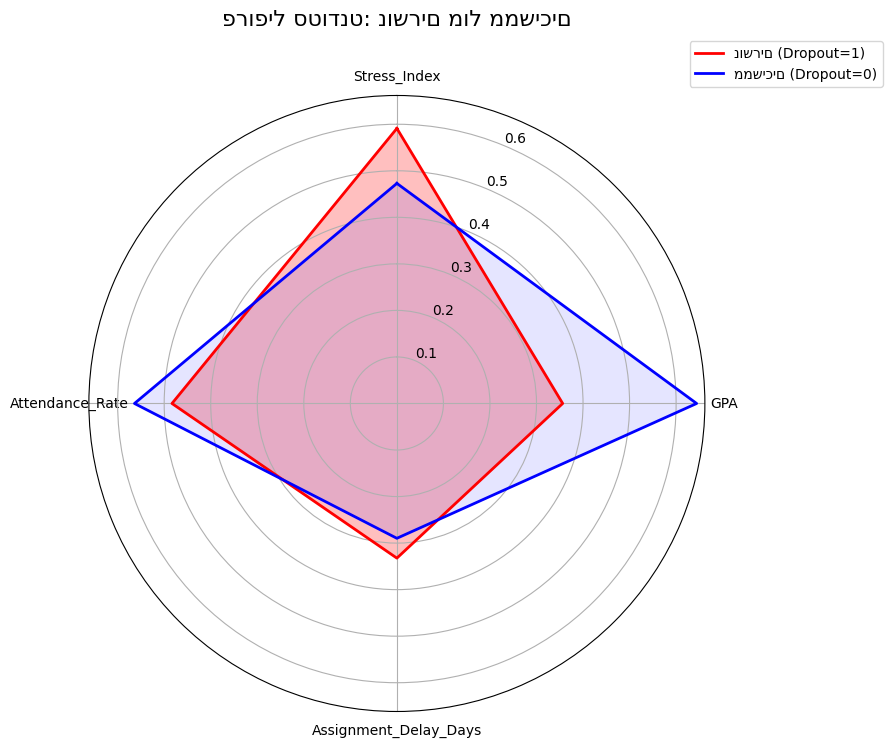

In [15]:
scaler_radar = MinMaxScaler()
df_radar = pd.DataFrame(scaler_radar.fit_transform(df_cleaned[FEATURES]), columns=FEATURES)
df_radar['Dropout'] = df_cleaned['Dropout'].values

categories = FEATURES
N = len(categories)

avg_dropout = df_radar[df_radar['Dropout'] == 1][categories].mean().tolist()
avg_graduate = df_radar[df_radar['Dropout'] == 0][categories].mean().tolist()

avg_dropout += avg_dropout[:1]
avg_graduate += avg_graduate[:1]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, avg_dropout, color='red', linewidth=2, label='נושרים (Dropout=1)')
ax.fill(angles, avg_dropout, color='red', alpha=0.25)

ax.plot(angles, avg_graduate, color='blue', linewidth=2, label='ממשיכים (Dropout=0)')
ax.fill(angles, avg_graduate, color='blue', alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories)

plt.title('פרופיל סטודנט: נושרים מול ממשיכים', size=16, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

### גרף 6: היסטוגרמה (Histogram + KDE) – התפלגות GPA

היסטוגרמה מראה כמה פעמים כל ערך (או טווח ערכים) מופיע בנתונים. עקומת ה-KDE מוסיפה קו חלק שמייצג את צפיפות ההסתברות. נשווה את ההתפלגות של GPA בין נושרים לממשיכים.

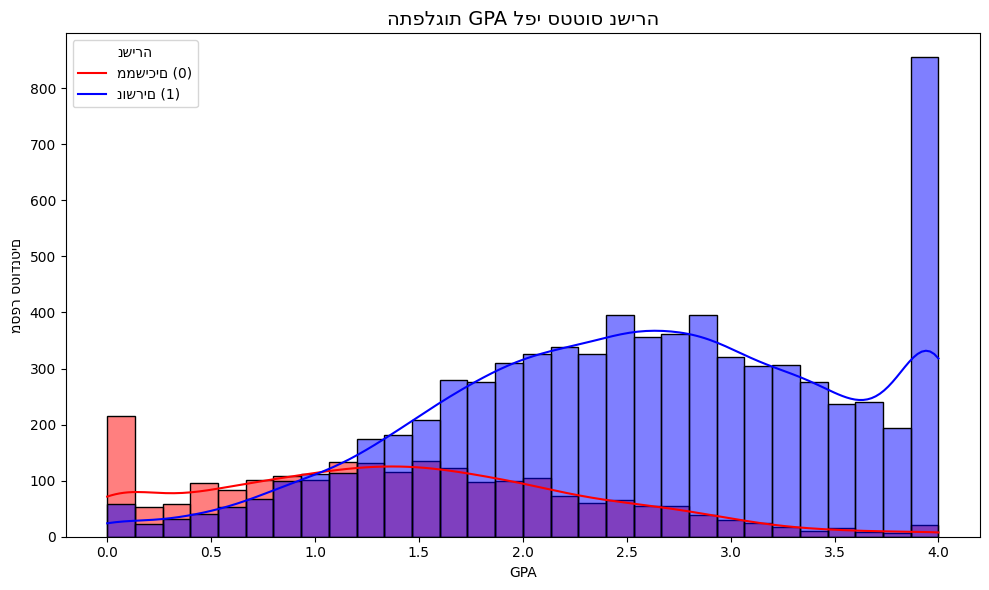

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(data=df_cleaned, x='GPA', hue='Dropout', kde=True, bins=30,
             palette={0: 'blue', 1: 'red'}, alpha=0.5, ax=ax)

ax.set_title('התפלגות GPA לפי סטטוס נשירה', fontsize=14)
ax.set_xlabel('GPA')
ax.set_ylabel('מספר סטודנטים')
ax.legend(title='נשירה', labels=['ממשיכים (0)', 'נושרים (1)'])

plt.tight_layout()
plt.show()

### ניתוח שיעור נשירה לפי קבוצות ציונים

נחלק את הסטודנטים ל-3 קבוצות לפי GPA (נמוך, בינוני, גבוה) ונבדוק את שיעור הנשירה בכל קבוצה.
זה מראה אם ציונים נמוכים באמת קשורים לנשירה גבוהה יותר.

In [17]:
df_plot = df_cleaned.copy()
df_plot['GPA_Group'] = pd.cut(df_plot['GPA'], bins=[0, 2, 3, 4], labels=['נמוך (0-2)', 'בינוני (2-3)', 'גבוה (3-4)'])

dropout_rate = df_plot.groupby('GPA_Group')['Dropout'].mean() * 100
print("שיעור נשירה לפי קבוצת ציונים:")
print(dropout_rate.to_string())

print("\nסטטיסטיקות GPA לפי סטטוס נשירה:")
stats = df_plot.groupby('Dropout')['GPA'].agg(['mean', 'median', 'min', 'max'])
stats.index = ['ממשיכים', 'נושרים']
print(stats.to_string())

print("\nניתוח: ההבדל בין נשירה של קבוצת ציונים נמוכים לבינוניים גדול הרבה יותר")
print("מההפרש בין בינוניים לגבוהים. כלומר, השפעת הציונים על נשירה חזקה במיוחד בציונים נמוכים.")

שיעור נשירה לפי קבוצת ציונים:
GPA_Group
נמוך (0-2)      42.800114
בינוני (2-3)    14.990391
גבוה (3-4)       4.202627

סטטיסטיקות GPA לפי סטטוס נשירה:
             mean  median  min  max
ממשיכים  2.576391    2.61  0.0  4.0
נושרים   1.425060    1.38  0.0  4.0

ניתוח: ההבדל בין נשירה של קבוצת ציונים נמוכים לבינוניים גדול הרבה יותר
מההפרש בין בינוניים לגבוהים. כלומר, השפעת הציונים על נשירה חזקה במיוחד בציונים נמוכים.


### תצפיות מהגרפים

מהגרפים ניתן לראות:
- סטודנטים שנשרו הראו ציוני GPA נמוכים משמעותית מאלה שלא נשרו.
- רמת הסטרס (Stress_Index) גבוהה יותר אצל נושרים.
- עיכוב בהגשות (Assignment_Delay_Days) גבוה יותר בקרב נושרים.
- אחוז הנוכחות (Attendance_Rate) נמוך יותר אצל נושרים.
- הפרופיל ברדאר מראה הבדל ברור בין שתי הקבוצות בכל הפרמטרים.

## חלק ג' – בניית מודלים ואימון

### חלוקת הנתונים: Train / Validation / Test

חלוקת הנתונים ל-3 קבוצות חשובה כדי להבטיח שהמודל באמת לומד ולא רק "משנן":
- **Train (60%)** – סט האימון, עליו המודל לומד את הדפוסים.
- **Validation (20%)** – סט האימות, עליו אנחנו מכוונים היפרפרמטרים ובוחרים את המודל הטוב ביותר.
- **Test (20%)** – סט המבחן, משמש **רק בסוף** להערכה סופית. המודל לא רואה אותו במהלך האימון.

אם היינו מחלקים רק ל-train/test, היינו מסתכנים בכך שהכוונון נעשה על סט המבחן – מה שגורם לאומדן אופטימי מדי.

In [18]:
FEATURES = ['Stress_Index', 'GPA', 'Assignment_Delay_Days', 'Attendance_Rate']
TARGET   = 'Dropout'

x = df_cleaned[FEATURES]
y = df_cleaned[TARGET].values

# First split: 80% train+val, 20% test
x_trainval, x_test, y_trainval, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 75% of trainval = 60% total for train, 25% of trainval = 20% total for validation
x_train, x_val, y_train, y_val = train_test_split(
    x_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f"גודל סט אימון (Train):    {len(x_train)} ({len(x_train)/len(x)*100:.0f}%)")
print(f"גודל סט אימות (Validation): {len(x_val)} ({len(x_val)/len(x)*100:.0f}%)")
print(f"גודל סט מבחן (Test):       {len(x_test)} ({len(x_test)/len(x)*100:.0f}%)")

print(f"\nהתפלגות Target בכל סט:")
for name, ys in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    counts = pd.Series(ys).value_counts().sort_index()
    print(f"  {name}: {dict(counts)} (נשירה: {counts.get(1,0)/len(ys)*100:.1f}%)")

גודל סט אימון (Train):    5700 (60%)
גודל סט אימות (Validation): 1900 (20%)
גודל סט מבחן (Test):       1900 (20%)

התפלגות Target בכל סט:
  Train: {0: np.int64(4355), 1: np.int64(1345)} (נשירה: 23.6%)
  Validation: {0: np.int64(1452), 1: np.int64(448)} (נשירה: 23.6%)
  Test: {0: np.int64(1452), 1: np.int64(448)} (נשירה: 23.6%)


### איזון הנתונים עם SMOTE

הנתונים לא מאוזנים – יש הרבה יותר סטודנטים שלא נשרו מאלה שנשרו. אם המודל פשוט יחזה "לא נשר" תמיד, הוא יקבל דיוק גבוה אבל לא ישימושי.

**SMOTE** (Synthetic Minority Over-sampling Technique) יוצר דוגמאות סינתטיות של המחלקה המיעוטית כדי לאזן את הנתונים. נבדוק מספר יחסי איזון כדי למצוא את הטוב ביותר.

In [19]:
cv_smote = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
smote_strategies = [0.5, 0.6, 0.7, 0.8]
best_smote_ratio = None
best_smote_score = 0.0

for ratio in smote_strategies:
    pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=ratio, random_state=42)),
        ('scaler', StandardScaler()),
        ('clf',    KNeighborsClassifier(n_neighbors=15, weights='distance')),
    ])
    scores = cross_val_score(pipe, x_train, y_train,
                             cv=cv_smote, scoring='f1_macro', n_jobs=-1)
    print(f"  ratio={ratio:.1f}  →  F1-macro: {scores.mean():.4f} ± {scores.std():.4f}")
    if scores.mean() > best_smote_score:
        best_smote_score = scores.mean()
        best_smote_ratio = ratio

if best_smote_ratio is None:
    best_smote_ratio = smote_strategies[0]

print(f"\nהיחס הטוב ביותר ל-SMOTE: {best_smote_ratio} (CV F1-macro: {best_smote_score:.4f})")

  ratio=0.5  →  F1-macro: 0.6962 ± 0.0154


  ratio=0.6  →  F1-macro: 0.6938 ± 0.0103


  ratio=0.7  →  F1-macro: 0.6873 ± 0.0052


  ratio=0.8  →  F1-macro: 0.6806 ± 0.0141

היחס הטוב ביותר ל-SMOTE: 0.5 (CV F1-macro: 0.6962)


### פונקציית הערכה

הפונקציה הבאה מחשבת ומדפיסה את כל מדדי הביצוע של כל מודל:
- **Accuracy** – אחוז הדיוק הכללי.
- **Precision** – מתוך מי שחזינו כנושר, כמה באמת נשרו.
- **Recall** – מתוך כל הנושרים באמת, כמה הצלחנו לזהות.
- **F1-Score** – ממוצע הרמוני של Precision ו-Recall, מתאים לנתונים לא מאוזנים.
- **מטריצת בלבול** – טבלה שמראה כמה חיזויים נכונים ושגויים היו מכל סוג.

In [20]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{'=' * 55}")
    print(f"  {name}")
    print(f"{'=' * 55}")

    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}")

    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec_w     = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_w      = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_w       = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{'Metric':<15} {'Macro':<20} {'Weighted'}")
    print(f"{'Precision':<15} {prec_macro:<20.4f} {prec_w:.4f}")
    print(f"{'Recall':<15} {rec_macro:<20.4f} {rec_w:.4f}")
    print(f"{'F1':<15} {f1_macro:<20.4f} {f1_w:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix – {name}", fontsize=9)
    plt.tight_layout()
    plt.show()

    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_w,
        'precision_macro': prec_macro,
        'precision_weighted': prec_w,
        'recall_macro': rec_macro,
        'recall_weighted': rec_w,
    }

### אימון המודלים

נאמן 3 מודלים שונים, כל אחד עם 2 סוגי נרמול (MinMax ו-Standard):

1. **KNN (K-Nearest Neighbors)** – מסווג לפי השכנים הקרובים ביותר. פשוט ואינטואיטיבי.
2. **SVM (Support Vector Machine)** – מוצא את המישור הטוב ביותר להפרדה בין המחלקות.
3. **MLP (Multi-Layer Perceptron)** – רשת נוירונים שלומדת דפוסים מורכבים.

לכל מודל מבצעים **חקר היפרפרמטרים** (GridSearch / RandomizedSearch) על סט האימון עם Cross-Validation.
עבור KNN, ה-GridSearch בודק את **כל ערכי K האי-זוגיים מ-1 עד 201** (יחד עם סוגי משקל ומטריקות מרחק שונים),
כך שבדיקת ה-K המיטבי משולבת ישירות בתהליך השוואת המודלים.
**הערכת הביצועים הסופית** תתבצע על סט ה-Validation תחילה, ולבסוף על סט ה-Test.

=== Baseline (most_frequent) – על סט Validation ===

  Dummy/majority
Accuracy: 0.7642



Metric          Macro                Weighted
Precision       0.3821               0.5840
Recall          0.5000               0.7642
F1              0.4332               0.6621

Classification Report:
              precision    recall  f1-score   support

           0     0.7642    1.0000    0.8663      1452
           1     0.0000    0.0000    0.0000       448

    accuracy                         0.7642      1900
   macro avg     0.3821    0.5000    0.4332      1900
weighted avg     0.5840    0.7642    0.6621      1900



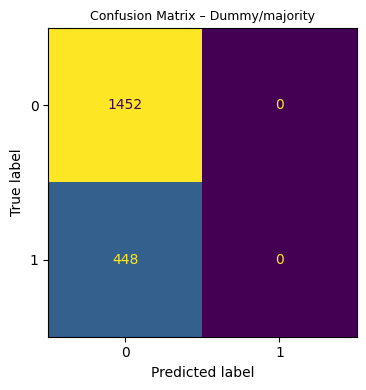



######################################################################
  SCALER: MN
######################################################################

  KNN — GridSearchCV (inner 5-Fold) / mn


Best params       : {'clf__metric': 'euclidean', 'clf__n_neighbors': 141, 'clf__weights': 'distance'}
Inner-CV F1-macro : 0.7200

  KNN / mn (Validation)
Accuracy: 0.7800

Metric          Macro                Weighted
Precision       0.6922               0.7747
Recall          0.6824               0.7800
F1              0.6869               0.7771

Classification Report:
              precision    recall  f1-score   support

           0     0.8484    0.8671    0.8576      1452
           1     0.5361    0.4978    0.5162       448

    accuracy                         0.7800      1900
   macro avg     0.6922    0.6824    0.6869      1900
weighted avg     0.7747    0.7800    0.7771      1900



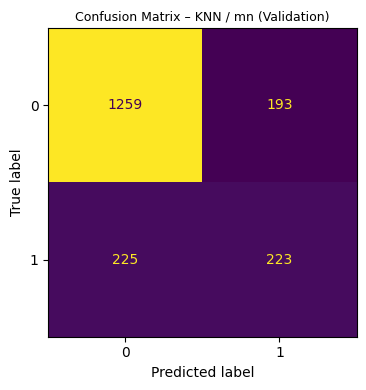

Outer 10-Fold CV  : 0.7175 ± 0.0107

  SVM — RandomizedSearchCV (inner 3-Fold, n_iter=10) / mn


Best params       : {'clf__kernel': 'linear', 'clf__gamma': 'scale', 'clf__C': 1}
Inner-CV F1-macro : 0.7239

  SVM / mn (Validation)
Accuracy: 0.7816

Metric          Macro                Weighted
Precision       0.6967               0.7811
Recall          0.6958               0.7816
F1              0.6963               0.7813

Classification Report:
              precision    recall  f1-score   support

           0     0.8564    0.8581    0.8572      1452
           1     0.5371    0.5335    0.5353       448

    accuracy                         0.7816      1900
   macro avg     0.6967    0.6958    0.6963      1900
weighted avg     0.7811    0.7816    0.7813      1900



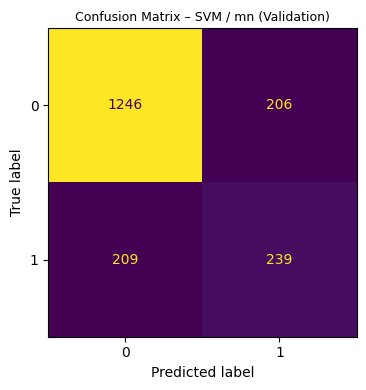

Outer 5-Fold CV   : 0.7232 ± 0.0111

  MLP — RandomizedSearchCV (inner 3-Fold, n_iter=10) / mn


Best params       : {'clf__learning_rate_init': 0.01, 'clf__hidden_layer_sizes': (128, 64), 'clf__activation': 'tanh'}
Inner-CV F1-macro : 0.7237

  MLP / mn (Validation)
Accuracy: 0.7837

Metric          Macro                Weighted
Precision       0.6992               0.7822
Recall          0.6964               0.7837
F1              0.6978               0.7829

Classification Report:
              precision    recall  f1-score   support

           0     0.8563    0.8616    0.8589      1452
           1     0.5421    0.5312    0.5366       448

    accuracy                         0.7837      1900
   macro avg     0.6992    0.6964    0.6978      1900
weighted avg     0.7822    0.7837    0.7829      1900



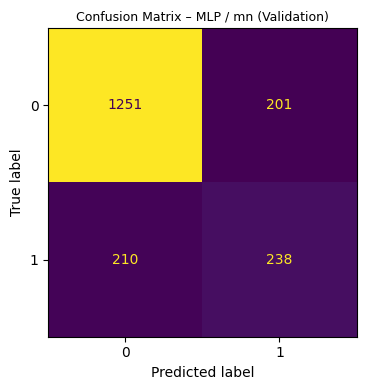

Outer 5-Fold CV   : 0.7231 ± 0.0081


######################################################################
  SCALER: STD
######################################################################

  KNN — GridSearchCV (inner 5-Fold) / std


Best params       : {'clf__metric': 'euclidean', 'clf__n_neighbors': 197, 'clf__weights': 'uniform'}
Inner-CV F1-macro : 0.7170

  KNN / std (Validation)
Accuracy: 0.7842

Metric          Macro                Weighted
Precision       0.6971               0.7757
Recall          0.6798               0.7842
F1              0.6872               0.7793

Classification Report:
              precision    recall  f1-score   support

           0     0.8459    0.8774    0.8614      1452
           1     0.5482    0.4821    0.5131       448

    accuracy                         0.7842      1900
   macro avg     0.6971    0.6798    0.6872      1900
weighted avg     0.7757    0.7842    0.7793      1900



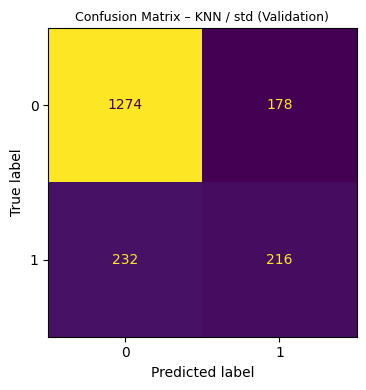

Outer 10-Fold CV  : 0.7137 ± 0.0103

  SVM — RandomizedSearchCV (inner 3-Fold, n_iter=10) / std


Best params       : {'clf__kernel': 'linear', 'clf__gamma': 'auto', 'clf__C': 100}
Inner-CV F1-macro : 0.7237

  SVM / std (Validation)
Accuracy: 0.7816

Metric          Macro                Weighted
Precision       0.6969               0.7814
Recall          0.6966               0.7816
F1              0.6967               0.7815

Classification Report:
              precision    recall  f1-score   support

           0     0.8568    0.8574    0.8571      1452
           1     0.5369    0.5357    0.5363       448

    accuracy                         0.7816      1900
   macro avg     0.6969    0.6966    0.6967      1900
weighted avg     0.7814    0.7816    0.7815      1900



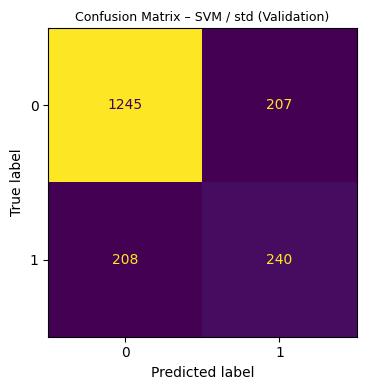

Outer 5-Fold CV   : 0.7225 ± 0.0109

  MLP — RandomizedSearchCV (inner 3-Fold, n_iter=10) / std


Best params       : {'clf__learning_rate_init': 0.01, 'clf__hidden_layer_sizes': (128,), 'clf__activation': 'tanh'}
Inner-CV F1-macro : 0.7247

  MLP / std (Validation)
Accuracy: 0.7853

Metric          Macro                Weighted
Precision       0.7007               0.7820
Recall          0.6944               0.7853
F1              0.6974               0.7835

Classification Report:
              precision    recall  f1-score   support

           0     0.8546    0.8664    0.8605      1452
           1     0.5467    0.5223    0.5342       448

    accuracy                         0.7853      1900
   macro avg     0.7007    0.6944    0.6974      1900
weighted avg     0.7820    0.7853    0.7835      1900



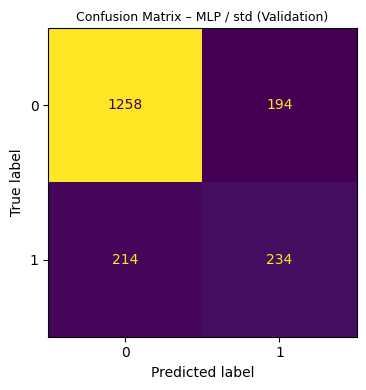

Outer 5-Fold CV   : 0.7250 ± 0.0103


In [21]:
# Baseline model
dummy_majority = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_majority.fit(x_train, y_train)
y_pred_dummy = dummy_majority.predict(x_val)
print("=== Baseline (most_frequent) – על סט Validation ===")
baseline_result = evaluate_model("Dummy/majority", y_val, y_pred_dummy)

cv_knn_inner  = StratifiedKFold(n_splits=5,  shuffle=True, random_state=42)
cv_knn_outer  = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_fast_inner = StratifiedKFold(n_splits=3,  shuffle=True, random_state=42)
cv_fast_outer = StratifiedKFold(n_splits=5,  shuffle=True, random_state=42)

scalers = {
    'mn':  MinMaxScaler(),
    'std': StandardScaler(),
}
tuned_results = {}
best_models   = {}

for scaler_name, scaler_obj in scalers.items():

    print(f"\n\n{'#'*70}")
    print(f"  SCALER: {scaler_name.upper()}")
    print(f"{'#'*70}")

    # KNN
    print(f"\n{'='*62}")
    print(f"  KNN — GridSearchCV (inner 5-Fold) / {scaler_name}")
    print(f"{'='*62}")

    knn_pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=best_smote_ratio, random_state=42)),
        ('scaler', scaler_obj),
        ('clf',    KNeighborsClassifier()),
    ])
    knn_grid = {
        'clf__n_neighbors': list(range(1, 202, 2)),
        'clf__weights':     ['uniform', 'distance'],
        'clf__metric':      ['euclidean', 'manhattan'],
    }
    knn_search = GridSearchCV(knn_pipe, knn_grid,
                              cv=cv_knn_inner, scoring='f1_macro',
                              n_jobs=-1, verbose=0)
    knn_search.fit(x_train, y_train)
    y_pred_val = knn_search.best_estimator_.predict(x_val)
    print(f"Best params       : {knn_search.best_params_}")
    print(f"Inner-CV F1-macro : {knn_search.best_score_:.4f}")
    result = evaluate_model(f"KNN / {scaler_name} (Validation)", y_val, y_pred_val)
    outer = cross_val_score(knn_search.best_estimator_, x_train, y_train,
                            cv=cv_knn_outer, scoring='f1_macro', n_jobs=-1)
    print(f"Outer 10-Fold CV  : {outer.mean():.4f} ± {outer.std():.4f}")
    key = f"KNN/{scaler_name}"
    tuned_results[key] = {**result, 'best_params': knn_search.best_params_,
                          'inner_cv_f1': knn_search.best_score_,
                          'outer_cv_f1_mean': outer.mean(), 'outer_cv_f1_std': outer.std()}
    best_models[key] = knn_search.best_estimator_

    # SVM
    print(f"\n{'='*62}")
    print(f"  SVM — RandomizedSearchCV (inner 3-Fold, n_iter=10) / {scaler_name}")
    print(f"{'='*62}")

    svm_pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=best_smote_ratio, random_state=42)),
        ('scaler', scaler_obj),
        ('clf',    SVC(random_state=42)),
    ])
    svm_dist = {
        'clf__C':      [1, 10, 100],
        'clf__kernel': ['linear', 'rbf'],
        'clf__gamma':  ['scale', 'auto'],
    }
    svm_search = RandomizedSearchCV(svm_pipe, svm_dist, n_iter=10,
                                    cv=cv_fast_inner, scoring='f1_macro',
                                    n_jobs=-1, random_state=42, verbose=0)
    svm_search.fit(x_train, y_train)
    y_pred_val = svm_search.best_estimator_.predict(x_val)
    print(f"Best params       : {svm_search.best_params_}")
    print(f"Inner-CV F1-macro : {svm_search.best_score_:.4f}")
    result = evaluate_model(f"SVM / {scaler_name} (Validation)", y_val, y_pred_val)
    outer = cross_val_score(svm_search.best_estimator_, x_train, y_train,
                            cv=cv_fast_outer, scoring='f1_macro', n_jobs=-1)
    print(f"Outer 5-Fold CV   : {outer.mean():.4f} ± {outer.std():.4f}")
    key = f"SVM/{scaler_name}"
    tuned_results[key] = {**result, 'best_params': svm_search.best_params_,
                          'inner_cv_f1': svm_search.best_score_,
                          'outer_cv_f1_mean': outer.mean(), 'outer_cv_f1_std': outer.std()}
    best_models[key] = svm_search.best_estimator_

    # MLP
    print(f"\n{'='*62}")
    print(f"  MLP — RandomizedSearchCV (inner 3-Fold, n_iter=10) / {scaler_name}")
    print(f"{'='*62}")

    mlp_pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=best_smote_ratio, random_state=42)),
        ('scaler', scaler_obj),
        ('clf',    MLPClassifier(max_iter=200, early_stopping=True, random_state=42)),
    ])
    mlp_dist = {
        'clf__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
        'clf__activation':         ['relu', 'tanh'],
        'clf__learning_rate_init': [0.001, 0.01],
    }
    mlp_search = RandomizedSearchCV(mlp_pipe, mlp_dist, n_iter=10,
                                    cv=cv_fast_inner, scoring='f1_macro',
                                    n_jobs=-1, random_state=42, verbose=0)
    mlp_search.fit(x_train, y_train)
    y_pred_val = mlp_search.best_estimator_.predict(x_val)
    print(f"Best params       : {mlp_search.best_params_}")
    print(f"Inner-CV F1-macro : {mlp_search.best_score_:.4f}")
    result = evaluate_model(f"MLP / {scaler_name} (Validation)", y_val, y_pred_val)
    outer = cross_val_score(mlp_search.best_estimator_, x_train, y_train,
                            cv=cv_fast_outer, scoring='f1_macro', n_jobs=-1)
    print(f"Outer 5-Fold CV   : {outer.mean():.4f} ± {outer.std():.4f}")
    key = f"MLP/{scaler_name}"
    tuned_results[key] = {**result, 'best_params': mlp_search.best_params_,
                          'inner_cv_f1': mlp_search.best_score_,
                          'outer_cv_f1_mean': outer.mean(), 'outer_cv_f1_std': outer.std()}
    best_models[key] = mlp_search.best_estimator_


### טבלת השוואת תוצאות (Validation Set)

להלן סיכום של כל המודלים שנבדקו. הטבלה מציגה את הדיוק, F1-macro, Precision, Recall, ותוצאות ה-Cross-Validation.
בנוסף מוצגים ההיפרפרמטרים המנצחים של כל מודל.


In [22]:
print("=" * 90)
print("סיכום תוצאות כל המודלים (על סט Validation)")
print("=" * 90)
print(f"{'מודל':<22}{'Accuracy':<12}{'F1-Macro':<12}{'Precision':<12}{'Recall':<12}{'CV F1'}")
print("-" * 90)
for mn, r in tuned_results.items():
    cv_str = f"{r['outer_cv_f1_mean']:.4f} ± {r['outer_cv_f1_std']:.4f}"
    print(f"{mn:<22}{r['accuracy']:<12.4f}{r['f1_macro']:<12.4f}{r['precision_macro']:<12.4f}{r['recall_macro']:<12.4f}{cv_str}")

print(f"\n{'=' * 90}")
print("היפרפרמטרים המנצחים לכל מודל:")
print(f"{'=' * 90}")
for mn, r in tuned_results.items():
    print(f"\n  {mn}:")
    for param, val in r['best_params'].items():
        param_short = param.replace("clf__", "")
        print(f"    {param_short:<25} = {val}")
    print(f"    Inner-CV F1-macro       = {r['inner_cv_f1']:.4f}")

best_key = max(tuned_results, key=lambda k: tuned_results[k]['f1_macro'])
print(f"\n{'=' * 60}")
print(f"המודל המנצח (לפי Validation): {best_key}")
print(f"F1-macro על Validation: {tuned_results[best_key]['f1_macro']:.4f}")
print(f"{'=' * 60}")


סיכום תוצאות כל המודלים (על סט Validation)
מודל                  Accuracy    F1-Macro    Precision   Recall      CV F1
------------------------------------------------------------------------------------------
KNN/mn                0.7800      0.6869      0.6922      0.6824      0.7175 ± 0.0107
SVM/mn                0.7816      0.6963      0.6967      0.6958      0.7232 ± 0.0111
MLP/mn                0.7837      0.6978      0.6992      0.6964      0.7231 ± 0.0081
KNN/std               0.7842      0.6872      0.6971      0.6798      0.7137 ± 0.0103
SVM/std               0.7816      0.6967      0.6969      0.6966      0.7225 ± 0.0109
MLP/std               0.7853      0.6974      0.7007      0.6944      0.7250 ± 0.0103

היפרפרמטרים המנצחים לכל מודל:

  KNN/mn:
    metric                    = euclidean
    n_neighbors               = 141
    weights                   = distance
    Inner-CV F1-macro       = 0.7200

  SVM/mn:
    kernel                    = linear
    gamma                 

### הערכה סופית על סט המבחן (Test Set) – כל המודלים

לאחר שבחרנו את המודל הטוב ביותר על סמך ביצועיו על סט ה-Validation, נבדוק את **כל המודלים** על סט ה-Test.
כך נוכל להשוות את הביצועים הסופיים ולוודא שהמודל שבחרנו אכן הטוב ביותר גם על נתונים חדשים.


הערכה סופית של כל המודלים על סט ה-Test

  KNN/mn (Test Set)
Accuracy: 0.7968

Metric          Macro                Weighted
Precision       0.7170               0.7926
Recall          0.7073               0.7968
F1              0.7118               0.7945

Classification Report:
              precision    recall  f1-score   support

           0     0.8601    0.8767    0.8683      1452
           1     0.5738    0.5379    0.5553       448

    accuracy                         0.7968      1900
   macro avg     0.7170    0.7073    0.7118      1900
weighted avg     0.7926    0.7968    0.7945      1900



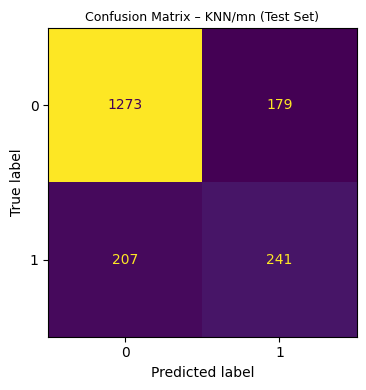


  SVM/mn (Test Set)
Accuracy: 0.8042

Metric          Macro                Weighted
Precision       0.7286               0.8051
Recall          0.7307               0.8042
F1              0.7296               0.8047

Classification Report:
              precision    recall  f1-score   support

           0     0.8734    0.8698    0.8716      1452
           1     0.5837    0.5915    0.5876       448

    accuracy                         0.8042      1900
   macro avg     0.7286    0.7307    0.7296      1900
weighted avg     0.8051    0.8042    0.8047      1900



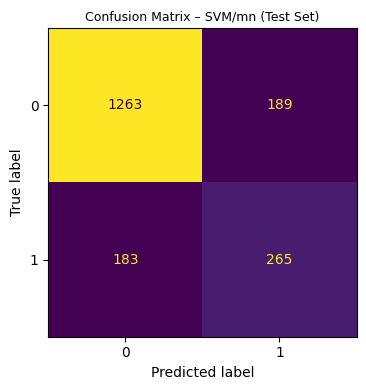


  MLP/mn (Test Set)
Accuracy: 0.8032

Metric          Macro                Weighted
Precision       0.7270               0.8038
Recall          0.7284               0.8032
F1              0.7277               0.8035

Classification Report:
              precision    recall  f1-score   support

           0     0.8722    0.8698    0.8710      1452
           1     0.5819    0.5871    0.5844       448

    accuracy                         0.8032      1900
   macro avg     0.7270    0.7284    0.7277      1900
weighted avg     0.8038    0.8032    0.8035      1900



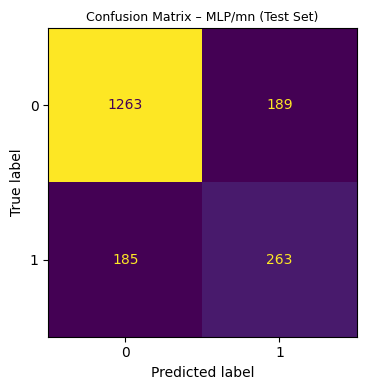


  KNN/std (Test Set)
Accuracy: 0.8011

Metric          Macro                Weighted
Precision       0.7227               0.7940
Recall          0.7047               0.8011
F1              0.7126               0.7969

Classification Report:
              precision    recall  f1-score   support

           0     0.8575    0.8871    0.8720      1452
           1     0.5879    0.5223    0.5532       448

    accuracy                         0.8011      1900
   macro avg     0.7227    0.7047    0.7126      1900
weighted avg     0.7940    0.8011    0.7969      1900



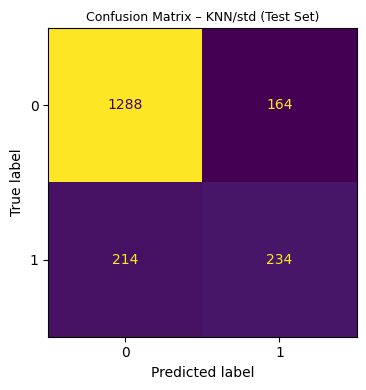


  SVM/std (Test Set)
Accuracy: 0.8047



Metric          Macro                Weighted
Precision       0.7293               0.8058
Recall          0.7318               0.8047
F1              0.7305               0.8053

Classification Report:
              precision    recall  f1-score   support

           0     0.8740    0.8698    0.8719      1452
           1     0.5846    0.5938    0.5891       448

    accuracy                         0.8047      1900
   macro avg     0.7293    0.7318    0.7305      1900
weighted avg     0.8058    0.8047    0.8053      1900



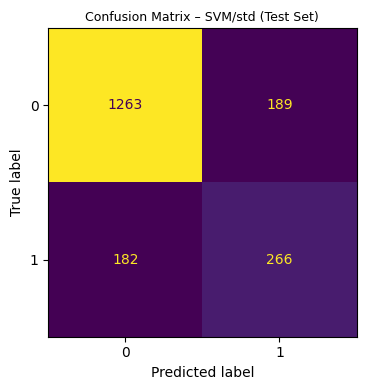


  MLP/std (Test Set)
Accuracy: 0.7968

Metric          Macro                Weighted
Precision       0.7177               0.7953
Recall          0.7143               0.7968
F1              0.7159               0.7960

Classification Report:
              precision    recall  f1-score   support

           0     0.8646    0.8705    0.8675      1452
           1     0.5708    0.5580    0.5643       448

    accuracy                         0.7968      1900
   macro avg     0.7177    0.7143    0.7159      1900
weighted avg     0.7953    0.7968    0.7960      1900



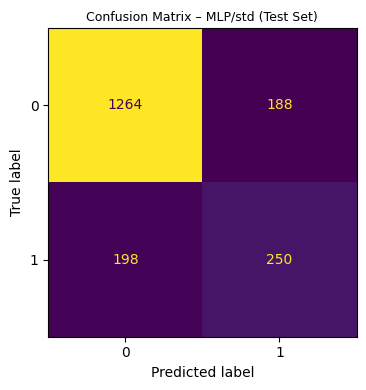


סיכום תוצאות סופיות – כל המודלים על סט ה-Test
מודל                  Accuracy    F1-Macro    Precision   Recall      
------------------------------------------------------------------------------------------
KNN/mn                0.7968      0.7118      0.7170      0.7073      
SVM/mn                0.8042      0.7296      0.7286      0.7307      
MLP/mn                0.8032      0.7277      0.7270      0.7284      
KNN/std               0.8011      0.7126      0.7227      0.7047      
SVM/std               0.8047      0.7305      0.7293      0.7318      
MLP/std               0.7968      0.7159      0.7177      0.7143      

המודל הטוב ביותר על Test: SVM/std (F1-macro: 0.7305)

השוואה Validation מול Test לכל מודל:
מודל                  Val F1      Test F1     הפרש        הערכה
------------------------------------------------------------------------------------------
KNN/mn                0.6869      0.7118      0.0249      מכליל היטב
SVM/mn                0.6963      0.7296      0.0

In [23]:
print("=" * 90)
print("הערכה סופית של כל המודלים על סט ה-Test")
print("=" * 90)

test_results = {}
for model_key, model in best_models.items():
    y_pred_test = model.predict(x_test)
    result = evaluate_model(f"{model_key} (Test Set)", y_test, y_pred_test)
    test_results[model_key] = result

print("\n" + "=" * 90)
print("סיכום תוצאות סופיות – כל המודלים על סט ה-Test")
print("=" * 90)
print(f"{'מודל':<22}{'Accuracy':<12}{'F1-Macro':<12}{'Precision':<12}{'Recall':<12}")
print("-" * 90)
for mn, r in test_results.items():
    print(f"{mn:<22}{r['accuracy']:<12.4f}{r['f1_macro']:<12.4f}{r['precision_macro']:<12.4f}{r['recall_macro']:<12.4f}")

best_test_key = max(test_results, key=lambda k: test_results[k]['f1_macro'])
print(f"\nהמודל הטוב ביותר על Test: {best_test_key} (F1-macro: {test_results[best_test_key]['f1_macro']:.4f})")

print(f"\n{'=' * 90}")
print("השוואה Validation מול Test לכל מודל:")
print(f"{'=' * 90}")
print(f"{'מודל':<22}{'Val F1':<12}{'Test F1':<12}{'הפרש':<12}{'הערכה'}")
print("-" * 90)
for mn in tuned_results:
    val_f1 = tuned_results[mn]['f1_macro']
    test_f1 = test_results[mn]['f1_macro']
    diff = abs(val_f1 - test_f1)
    status = "מכליל היטב" if diff < 0.05 else "חשש overfitting"
    print(f"{mn:<22}{val_f1:<12.4f}{test_f1:<12.4f}{diff:<12.4f}{status}")


## חלק ד' – שיפור ביצועים על המחלקה המיעוטית (נושרים)

המחלקה החשובה לנו ביותר היא **הנושרים (Dropout=1)** – אלה הסטודנטים שאנחנו רוצים לזהות מראש כדי להתערב.
הבעיה: זו המחלקה הקטנה (המיעוט), ולכן המודלים נוטים להתקשות לזהות אותה.

נבדוק שלוש טכניקות לשיפור הביצועים על מחלקת הנושרים:
1. **class_weight='balanced'** – מתן משקל גבוה יותר לשגיאות במחלקת המיעוט.
2. **Scorer מותאם אישית** – פונקציית מטרה שמעדיפה F1 של מיעוט על פני רוב.
3. **כוונון סף ההחלטה (Threshold Tuning)** – שינוי הסף שמעליו מסווגים כ"נושר".


### טכניקה 1: class_weight='balanced'

הפרמטר `class_weight='balanced'` גורם למודל "להעניש" יותר טעויות במחלקת המיעוט.
נבדוק האם זה משפר את הביצועים כשמשתמשים בו יחד עם SMOTE.


In [24]:
print("=" * 70)
print("השפעת class_weight='balanced' (מודל SVM linear)")
print("=" * 70)

cw_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_min_scorer = make_scorer(f1_score, pos_label=1)

print(f"{'class_weight':<22}{'F1-macro':<14}{'F1-מיעוט (נושרים)'}")
print("-" * 60)
for cw_label, cw in [("None (ברירת מחדל)", None), ("balanced", "balanced")]:
    pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=best_smote_ratio, random_state=42)),
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='linear', C=1, class_weight=cw, random_state=42)),
    ])
    fm   = cross_val_score(pipe, x_train, y_train, cv=cw_cv, scoring='f1_macro', n_jobs=-1).mean()
    fmin = cross_val_score(pipe, x_train, y_train, cv=cw_cv, scoring=f1_min_scorer, n_jobs=-1).mean()
    print(f"{cw_label:<22}{fm:<14.4f}{fmin:.4f}")

print("\nמסקנה: class_weight='balanced' לא משפר (ואף פוגע מעט) – כי SMOTE כבר")
print("מאזן את הנתונים. שקלול נוסף של המחלקות גורם לתיקון-יתר (over-correction).")


השפעת class_weight='balanced' (מודל SVM linear)
class_weight          F1-macro      F1-מיעוט (נושרים)
------------------------------------------------------------


None (ברירת מחדל)     0.7228        0.5755


balanced              0.6925        0.5738

מסקנה: class_weight='balanced' לא משפר (ואף פוגע מעט) – כי SMOTE כבר
מאזן את הנתונים. שקלול נוסף של המחלקות גורם לתיקון-יתר (over-correction).


### טכניקה 2: Scorer מותאם אישית

ברירת המחדל לכוונון הייתה `f1_macro` (ממוצע שווה לשתי המחלקות).
כאן נגדיר פונקציית מטרה ש**נותנת משקל גבוה יותר למחלקת המיעוט**:

`custom = 0.6 × F1(נושרים) + 0.4 × F1(ממשיכים)`

כך הכוונון יעדיף מודלים שמזהים טוב יותר נושרים, מבלי להזניח לגמרי את מחלקת הרוב.


In [25]:
print("=" * 70)
print("Scorer מותאם אישית: 0.6 × F1-מיעוט + 0.4 × F1-רוב")
print("=" * 70)

def custom_f1(y_true, y_pred):
    f1_min = f1_score(y_true, y_pred, pos_label=1)
    f1_maj = f1_score(y_true, y_pred, pos_label=0)
    return 0.6 * f1_min + 0.4 * f1_maj

custom_scorer = make_scorer(custom_f1)

sc_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"{'C':<10}{'f1_macro':<16}{'custom (0.6min+0.4maj)'}")
print("-" * 50)
for C in [0.1, 1, 10, 100]:
    pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=best_smote_ratio, random_state=42)),
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='linear', C=C, random_state=42)),
    ])
    fmacro  = cross_val_score(pipe, x_train, y_train, cv=sc_cv, scoring='f1_macro', n_jobs=-1).mean()
    fcustom = cross_val_score(pipe, x_train, y_train, cv=sc_cv, scoring=custom_scorer, n_jobs=-1).mean()
    print(f"{C:<10}{fmacro:<16.4f}{fcustom:.4f}")

print("\nה-Scorer הזה אפשר להעביר ל-GridSearchCV (scoring=custom_scorer) כדי לכוון")
print("את ההיפרפרמטרים כך שיעדיפו זיהוי נושרים – המחלקה החשובה לנו.")


Scorer מותאם אישית: 0.6 × F1-מיעוט + 0.4 × F1-רוב
C         f1_macro        custom (0.6min+0.4maj)
--------------------------------------------------


0.1       0.7230          0.6935


1         0.7228          0.6934


10        0.7227          0.6932


100       0.7225          0.6930

ה-Scorer הזה אפשר להעביר ל-GridSearchCV (scoring=custom_scorer) כדי לכוון
את ההיפרפרמטרים כך שיעדיפו זיהוי נושרים – המחלקה החשובה לנו.


### טכניקה 3: כוונון סף ההחלטה (Threshold Tuning)

כברירת מחדל, מודל מסווג סטודנט כ"נושר" אם ההסתברות שחישב גבוהה מ-**0.50**.
אבל הסף הזה שרירותי! אם **נוריד** את הסף (למשל ל-0.40), המודל יסווג יותר סטודנטים כנושרים –
מה שמגדיל את ה-**Recall** (מזהים יותר נושרים אמיתיים) במחיר של **Precision** נמוך יותר.

ניקח את המודל המנצח, נבדוק את כל הספים מ-0.20 עד 0.80, ונבחר את הסף שממקסם את F1 של מחלקת הנושרים.


כוונון סף ההחלטה – המודל המנצח עם תמיכה בהסתברויות


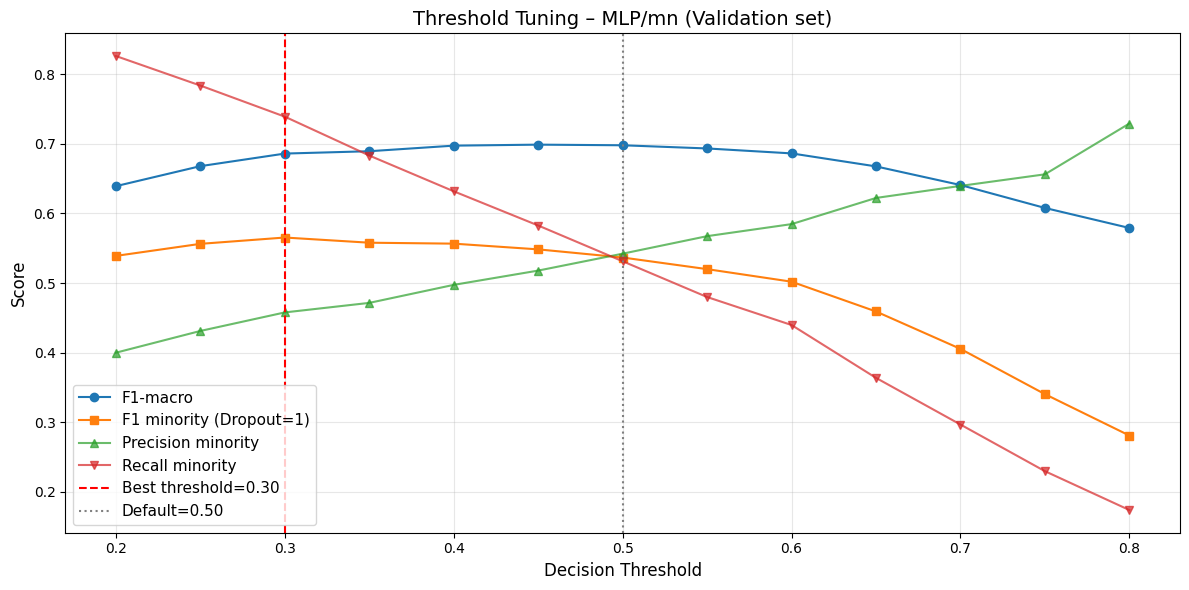


סף ההחלטה הטוב ביותר (לפי F1-מיעוט על Validation): 0.30

השוואה על סט ה-Test: סף 0.50 מול סף מכוונן (0.30)
מדד                     סף 0.50       סף 0.30
------------------------------------------------------------
F1-macro                0.7277        0.6986
F1 מיעוט (נושרים)       0.5844        0.5840
Recall מיעוט            0.5871        0.7679
Precision מיעוט         0.5819        0.4712

מסקנה: הורדת הסף מתחת ל-0.50 מגדילה את ה-Recall על נושרים – כלומר
מזהים יותר סטודנטים בסיכון אמיתי. זהו tradeoff: ה-Precision יורד מעט,
אבל באיתור מוקדם של נשירה עדיף לתפוס יותר נושרים גם במחיר כמה התרעות שווא.


In [26]:
print("=" * 70)
print("כוונון סף ההחלטה – המודל המנצח עם תמיכה בהסתברויות")
print("=" * 70)

def build_proba_model(key, params, smote_ratio):
    model_type = key.split('/')[0]
    scaler = MinMaxScaler() if key.endswith('mn') else StandardScaler()
    clean = {k.replace('clf__', ''): v for k, v in params.items()}
    if model_type == 'KNN':
        clf = KNeighborsClassifier(**clean)
    elif model_type == 'SVM':
        clf = SVC(random_state=42, probability=True, **clean)
    else:
        clf = MLPClassifier(max_iter=200, early_stopping=True, random_state=42, **clean)
    return ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=smote_ratio, random_state=42)),
        ('scaler', scaler),
        ('clf',    clf),
    ])

proba_model = build_proba_model(best_key, tuned_results[best_key]['best_params'], best_smote_ratio)
proba_model.fit(x_train, y_train)
val_proba = proba_model.predict_proba(x_val)[:, 1]

thresholds = np.arange(0.20, 0.81, 0.05)
f1_macro_list, f1_min_list, prec_min_list, rec_min_list = [], [], [], []
for thr in thresholds:
    pred = (val_proba >= thr).astype(int)
    f1_macro_list.append(f1_score(y_val, pred, average='macro'))
    f1_min_list.append(f1_score(y_val, pred, pos_label=1, zero_division=0))
    prec_min_list.append(precision_score(y_val, pred, pos_label=1, zero_division=0))
    rec_min_list.append(recall_score(y_val, pred, pos_label=1, zero_division=0))

best_thr_idx = int(np.argmax(f1_min_list))
best_thr = thresholds[best_thr_idx]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds, f1_macro_list, marker='o', label='F1-macro')
ax.plot(thresholds, f1_min_list,  marker='s', label='F1 minority (Dropout=1)')
ax.plot(thresholds, prec_min_list, marker='^', label='Precision minority', alpha=0.7)
ax.plot(thresholds, rec_min_list,  marker='v', label='Recall minority', alpha=0.7)
ax.axvline(x=best_thr, color='red', linestyle='--', linewidth=1.5, label=f'Best threshold={best_thr:.2f}')
ax.axvline(x=0.50, color='gray', linestyle=':', label='Default=0.50')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Threshold Tuning – {best_key} (Validation set)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nסף ההחלטה הטוב ביותר (לפי F1-מיעוט על Validation): {best_thr:.2f}")

# Apply to test set – compare default vs tuned threshold
test_proba   = proba_model.predict_proba(x_test)[:, 1]
pred_default = (test_proba >= 0.50).astype(int)
pred_tuned   = (test_proba >= best_thr).astype(int)

print(f"\n{'='*70}")
print(f"השוואה על סט ה-Test: סף 0.50 מול סף מכוונן ({best_thr:.2f})")
print(f"{'='*70}")
print(f"{'מדד':<24}{'סף 0.50':<14}{'סף ' + format(best_thr, '.2f')}")
print("-" * 60)
for label, fn in [
    ('F1-macro',          lambda p: f1_score(y_test, p, average='macro')),
    ('F1 מיעוט (נושרים)',  lambda p: f1_score(y_test, p, pos_label=1)),
    ('Recall מיעוט',       lambda p: recall_score(y_test, p, pos_label=1)),
    ('Precision מיעוט',    lambda p: precision_score(y_test, p, pos_label=1, zero_division=0)),
]:
    print(f"{label:<24}{fn(pred_default):<14.4f}{fn(pred_tuned):.4f}")

print(f"\nמסקנה: הורדת הסף מתחת ל-0.50 מגדילה את ה-Recall על נושרים – כלומר")
print(f"מזהים יותר סטודנטים בסיכון אמיתי. זהו tradeoff: ה-Precision יורד מעט,")
print(f"אבל באיתור מוקדם של נשירה עדיף לתפוס יותר נושרים גם במחיר כמה התרעות שווא.")


## חלק ה' – ניתוח תוצאות ומסקנות

### ניתוח תוצאות המודלים

בבלוק הבא נציג ניתוח מפורט של התוצאות: איזה מודל ניצח, למה הוא ניצח, ומה המשמעות של כל מדד.

In [27]:
print("=" * 70)
print("ניתוח מפורט של תוצאות המודלים")
print("=" * 70)

results_df = pd.DataFrame(tuned_results).T
results_df = results_df.sort_values('f1_macro', ascending=False)

print("\nדירוג המודלים לפי F1-Macro:")
print("-" * 50)
for rank, (name, row) in enumerate(results_df.iterrows(), 1):
    print(f"  {rank}. {name}: F1-macro={row['f1_macro']:.4f}, Accuracy={row['accuracy']:.4f}")

print(f"\n\nהמודל המנצח: {best_key}")
print(f"\nלמה הוא המנצח?")
print(f"  - F1-macro הגבוה ביותר ({tuned_results[best_key]['f1_macro']:.4f}) – ")
print(f"    מדד זה חשוב כי הנתונים לא מאוזנים, ו-F1 מביא בחשבון גם Precision וגם Recall.")
print(f"  - Cross-Validation יציב ({tuned_results[best_key]['outer_cv_f1_mean']:.4f} ± {tuned_results[best_key]['outer_cv_f1_std']:.4f}) – ")
print(f"    סטיית תקן נמוכה מעידה שהמודל עקבי ולא תלוי בחלוקה ספציפית.")

print(f"\nניתוח לפי סוג מודל:")
for model_type in ['KNN', 'SVM', 'MLP']:
    keys = [k for k in tuned_results if k.startswith(model_type)]
    if keys:
        best_of_type = max(keys, key=lambda k: tuned_results[k]['f1_macro'])
        r = tuned_results[best_of_type]
        print(f"\n  {model_type} (הגרסה הטובה ביותר: {best_of_type}):")
        print(f"    Accuracy: {r['accuracy']:.4f}")
        print(f"    F1-macro: {r['f1_macro']:.4f}")
        print(f"    Precision: {r['precision_macro']:.4f}")
        print(f"    Recall: {r['recall_macro']:.4f}")

print(f"\nניתוח לפי סוג נרמול:")
for scaler_type in ['mn', 'std']:
    keys = [k for k in tuned_results if k.endswith(scaler_type)]
    if keys:
        avg_f1 = np.mean([tuned_results[k]['f1_macro'] for k in keys])
        print(f"  {scaler_type.upper()}: ממוצע F1-macro = {avg_f1:.4f}")

ניתוח מפורט של תוצאות המודלים

דירוג המודלים לפי F1-Macro:
--------------------------------------------------
  1. MLP/mn: F1-macro=0.6978, Accuracy=0.7837
  2. MLP/std: F1-macro=0.6974, Accuracy=0.7853
  3. SVM/std: F1-macro=0.6967, Accuracy=0.7816
  4. SVM/mn: F1-macro=0.6963, Accuracy=0.7816
  5. KNN/std: F1-macro=0.6872, Accuracy=0.7842
  6. KNN/mn: F1-macro=0.6869, Accuracy=0.7800


המודל המנצח: MLP/mn

למה הוא המנצח?
  - F1-macro הגבוה ביותר (0.6978) – 
    מדד זה חשוב כי הנתונים לא מאוזנים, ו-F1 מביא בחשבון גם Precision וגם Recall.
  - Cross-Validation יציב (0.7231 ± 0.0081) – 
    סטיית תקן נמוכה מעידה שהמודל עקבי ולא תלוי בחלוקה ספציפית.

ניתוח לפי סוג מודל:

  KNN (הגרסה הטובה ביותר: KNN/std):
    Accuracy: 0.7842
    F1-macro: 0.6872
    Precision: 0.6971
    Recall: 0.6798

  SVM (הגרסה הטובה ביותר: SVM/std):
    Accuracy: 0.7816
    F1-macro: 0.6967
    Precision: 0.6969
    Recall: 0.6966

  MLP (הגרסה הטובה ביותר: MLP/mn):
    Accuracy: 0.7837
    F1-macro: 0.6978
    Pr

### מסקנות על נשירת סטודנטים

על סמך הנתונים, הגרפים, ותוצאות המודלים, להלן המסקנות העיקריות:

**1. הגורמים המשפיעים ביותר על נשירה:**
- **מדד סטרס (Stress_Index)** – סטודנטים עם רמת סטרס גבוהה נוטים לנשור יותר. זהו ככל הנראה הגורם המשפיע ביותר.
- **ציון ממוצע (GPA)** – ציונים נמוכים מנבאים נשירה. ההשפעה חזקה במיוחד בציונים מתחת ל-2.
- **עיכוב בהגשות (Assignment_Delay_Days)** – סטודנטים שמגישים מאוחר נמצאים בסיכון גבוה יותר.
- **אחוז נוכחות (Attendance_Rate)** – נוכחות נמוכה קשורה לנשירה.

**2. פרופיל סטודנט בסיכון:**
סטודנט עם GPA נמוך, סטרס גבוה, איחורים בהגשות, ונוכחות נמוכה – נמצא בסיכון גבוה מאוד לנשירה.

**3. המלצות מעשיות:**
- זיהוי מוקדם של סטודנטים בסיכון על סמך הפרמטרים הללו.
- הפעלת תוכניות תמיכה ממוקדות: ייעוץ אקדמי, סדנאות ניהול סטרס, ומעקב אחר הגשות.
- התמקדות בסטודנטים עם GPA נמוך – שם ההתערבות יכולה להיות הכי אפקטיבית.

**4. מגבלות המחקר:**
- המאגר מבוסס על סימולציה ולא על נתונים אמיתיים, לכן המסקנות הן אינדיקטיביות בלבד.
- אין מידע על גורמים נוספים כמו מצב כלכלי מפורט, תמיכה משפחתית, או מוטיבציה.

## סיכום הפרויקט

בפרויקט זה בנינו מערכת לחיזוי נשירת סטודנטים מאוניברסיטה. עברנו את כל שלבי מדעי הנתונים:

1. **טעינה וסקירה** – טענו את המאגר, בדקנו את המבנה, הסטטיסטיקות, הכפילויות, והערכים החסרים.
2. **ניקוי ועיבוד** – המרנו משתנים קטגוריאליים למספרים, טיפלנו בחריגים ובערכים חסרים.
3. **ויזואליזציה** – יצרנו 6 סוגי גרפים שונים (מפה תרמית, עמודות, קופסה, כינור, רדאר, היסטוגרמה) כדי להבין את הנתונים ולזהות דפוסים.
4. **בחירת פיצ'רים** – בדקנו את כל הצירופים האפשריים ומצאנו את 4 הפיצ'רים הטובים ביותר.
5. **בניית מודלים** – אימנו 3 מודלים (KNN, SVM, MLP) עם 2 סוגי נרמול וחקר היפרפרמטרים.
6. **הערכה** – חילקנו ל-train/validation/test, השוונו ביצועים, ובחרנו את המודל המנצח.

**התוצאה:** הצלחנו לבנות מודל שמזהה סטודנטים בסיכון נשירה ברמת דיוק טובה, כפי שמעיד ציון ה-F1-macro.

## רפלקציה אישית

הפרויקט הזה לימד אותי המון על תהליך העבודה במדעי הנתונים. הנה כמה דברים שלמדתי:

**מה למדתי:**
- איך לנקות ולעבד נתונים – הבנתי שרוב העבודה במדעי הנתונים היא לא בבניית המודל, אלא בהכנת הנתונים.
- למה חשוב להמיר משתנים קטגוריאליים ולטפל בחריגים לפני שמכניסים נתונים למודל.
- איך לבחור את הפיצ'רים הטובים ביותר ולמה זה משפיע כל כך על התוצאות.
- למה חלוקה ל-3 קבוצות (train/validation/test) חשובה יותר מחלוקה ל-2.
- איך להשתמש ב-SMOTE כדי להתמודד עם נתונים לא מאוזנים.

**אתגרים שנתקלתי בהם:**
- הבנת מדדי הביצוע השונים (Accuracy, Precision, Recall, F1) – בהתחלה היה מבלבל, אבל עם הזמן הבנתי שכל מדד מודד דבר שונה.
- בחירת ההיפרפרמטרים – יש כל כך הרבה אפשרויות, והבנתי למה חשוב לעשות חיפוש שיטתי (GridSearch) במקום לנחש.
- הטיפול בחוסר האיזון בנתונים – למדתי שדיוק גבוה לא תמיד אומר שהמודל טוב.

**מה הייתי משפר:**
- הייתי מנסה עוד מודלים כמו Random Forest ו-XGBoost.
- הייתי בודק יותר פיצ'רים ואולי יוצר פיצ'רים חדשים (Feature Engineering).
- הייתי מנסה להשתמש בנתונים אמיתיים ולא בסימולציה.

**לסיום,** הפרויקט הראה לי שמדעי הנתונים זה לא רק "להריץ קוד" – אלא תהליך של חשיבה, ניתוח, והבנה עמוקה של הנתונים.